In [3]:
import sklearn
import statsmodels
import tensorflow as tf
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as m
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

In [4]:
plt.style.use('fivethirtyeight')
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
m.rcParams['axes.labelsize'] = 14
m.rcParams['xtick.labelsize'] = 12
m.rcParams['ytick.labelsize'] = 12
m.rcParams['text.color'] = 'k'

In [5]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

tensorflow : 2.19.0
keras      : 3.10.0
numpy      : 1.26.4
sklearn    : 1.5.1
matplotlib : 3.9.2
seaborn    : 0.13.2
pandas     : 2.2.2
statsmodels: 0.14.2



In [6]:
df = pd.read_csv("C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/Dados/dataset_vendas1.csv")

<Axes: >

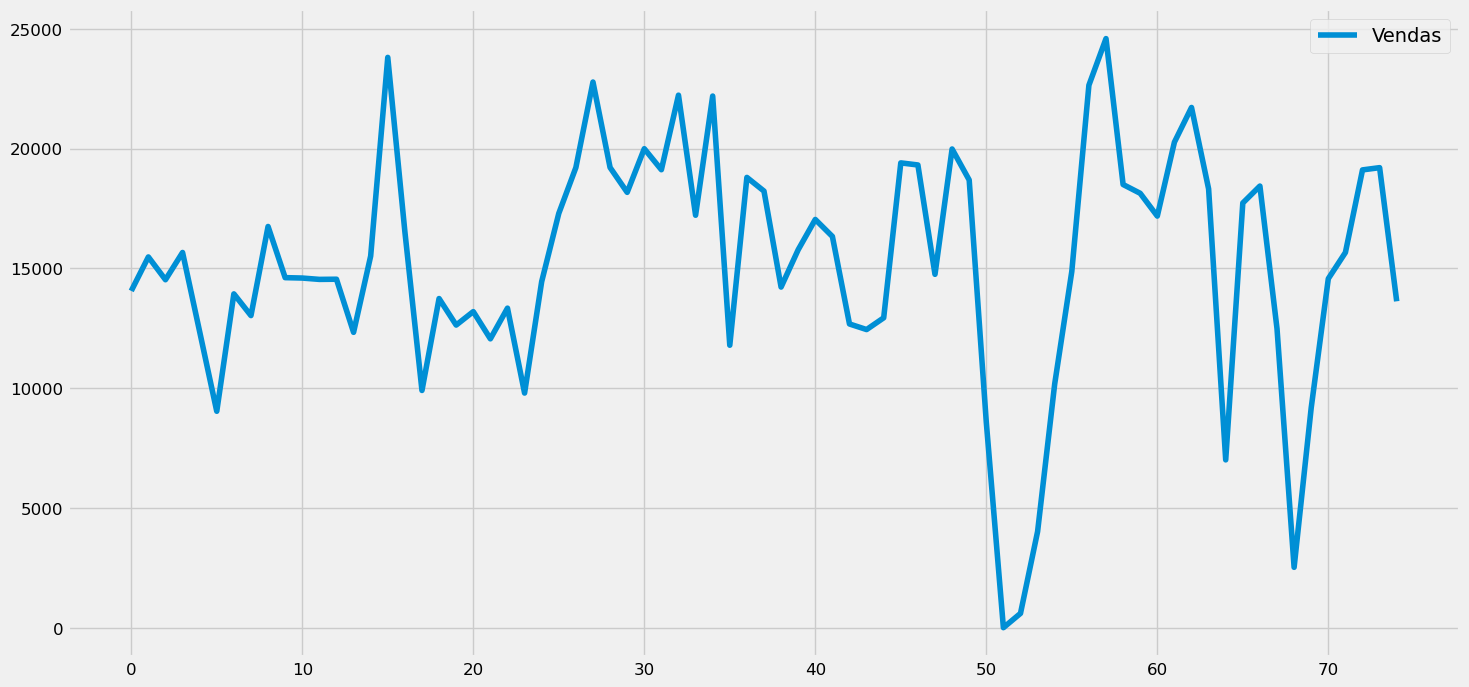

In [7]:
df.plot(figsize = (16, 8))

In [8]:
df.describe()

,Vendas
count,75.000000
mean,15189.320000
std,4938.414767
min,0.000000
25%,12805.500000
50%,15475.000000
75%,18592.000000
max,24589.000000


In [9]:
min_threshold = df['Vendas'].quantile(0.10)
print(min_threshold)

9425.2


In [10]:
amostra = df[df['Vendas'] < min_threshold]
print(amostra)

           Mes  Vendas
5   06-01-2016    9033
50  03-01-2020    8575
51  04-01-2020       0
52  05-01-2020     597
53  06-01-2020    4013
64  05-01-2021    7005
68  09-01-2021    2520
69  10-01-2021    9180


In [11]:
for i in range(75):
    if df.loc[i, 'Vendas'] < 9425.2:
        df.iat[i, 1] = 15190

In [12]:
df.head(6)

,Mes,Vendas
0,01-01-2016,14057
1,02-01-2016,15475
2,03-01-2016,14524
3,04-01-2016,15661
4,05-01-2016,12355
5,06-01-2016,15190


In [13]:
df.describe()

,Vendas
count,75.000000
mean,16263.946667
std,3296.759957
min,9793.000000
25%,14137.500000
50%,15475.000000
75%,18592.000000
max,24589.000000


In [14]:
df['Mes'] = pd.to_datetime(df['Mes'])

In [15]:
df.set_index('Mes', inplace=True)

In [16]:
df.head()

,Vendas
Mes,
2016-01-01,14057
2016-02-01,15475
2016-03-01,14524
2016-04-01,15661
2016-05-01,12355


In [17]:
resultado = seasonal_decompose(df['Vendas'])

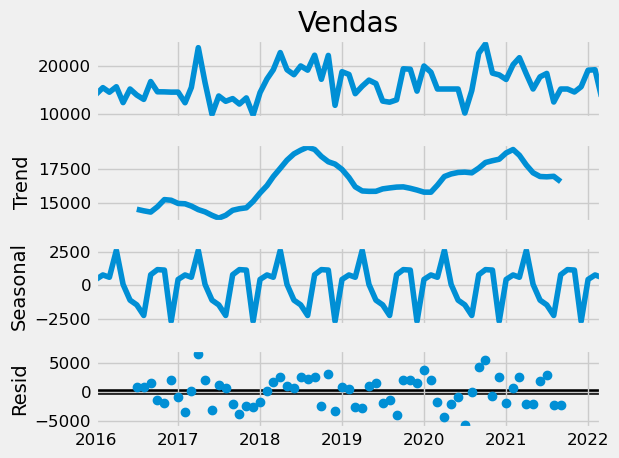

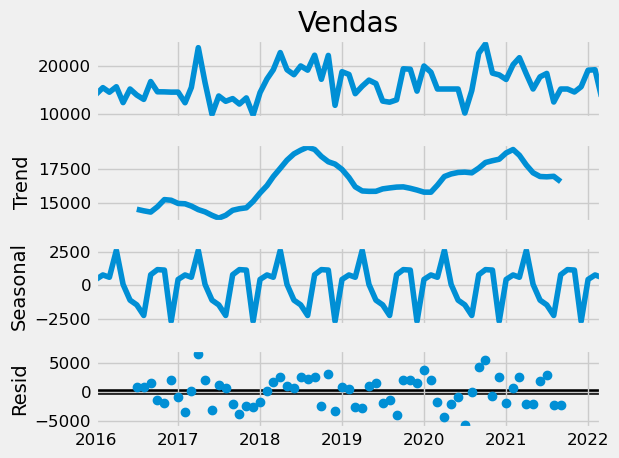

In [18]:
resultado.plot()

In [19]:
def testa_estacionaridade(serie):
    
    from statsmodels.tsa.stattools import adfuller
    
    # Calcula estatísticas móveis
    rolmean = serie.rolling(window = 12).mean()
    rolstd = serie.rolling(window = 12).std()

    # Plot das estatísticas móveis
    orig = plt.plot(serie, color = 'blue', label = 'Original')
    mean = plt.plot(rolmean, color = 'red', label = 'Média Móvel')
    std = plt.plot(rolstd, color = 'black', label = 'Desvio Padrão')
    
    # Plot
    plt.legend(loc = 'best')
    plt.title('Estatísticas Móveis - Média e Desvio Padrão')
    plt.show()
    
    # Teste Dickey-Fuller:
    # Print
    print('\nResultado do Teste Dickey-Fuller:\n')

    # Teste
    dfteste = adfuller(serie, autolag = 'AIC')

    # Formatando a saída
    dfsaida = pd.Series(dfteste[0:4], index = ['Estatística do Teste',
                                               'Valor-p',
                                               'Número de Lags Consideradas',
                                               'Número de Observações Usadas'])

    # Loop por cada item da saída do teste
    for key, value in dfteste[4].items():
        dfsaida['Valor Crítico (%s)'%key] = value

    # Print
    print (dfsaida)
    
    # Testa o valor-p
    print ('\nConclusão:')
    if dfsaida[1] > 0.05:
        print('\nO valor-p é maior que 0.05 e, portanto, não temos evidências para rejeitar a hipótese nula.')
        print('Essa série provavelmente não é estacionária.')
    else:
        print('\nO valor-p é menor que 0.05 e, portanto, temos evidências para rejeitar a hipótese nula.')
        print('Essa série provavelmente é estacionária.')

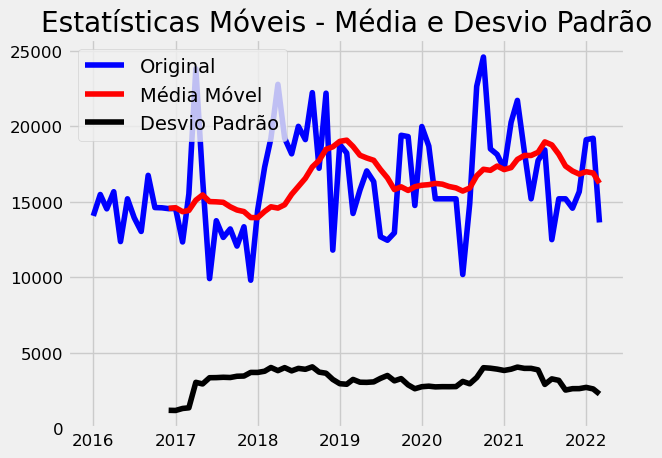


Resultado do Teste Dickey-Fuller:

Estatística do Teste            -5.520051
Valor-p                          0.000002
Número de Lags Consideradas      0.000000
Número de Observações Usadas    74.000000
Valor Crítico (1%)              -3.521980
Valor Crítico (5%)              -2.901470
Valor Crítico (10%)             -2.588072
dtype: float64

Conclusão:

O valor-p é menor que 0.05 e, portanto, temos evidências para rejeitar a hipótese nula.
Essa série provavelmente é estacionária.


In [20]:
testa_estacionaridade(df)

In [21]:
dados_treino = df.iloc[:63]
dados_teste = df.iloc[63:]

In [22]:
scaler = MinMaxScaler()

In [23]:
scaler.fit(dados_treino)

MinMaxScaler()

In [24]:
scaled_treino = scaler.transform(dados_treino)
scaled_teste = scaler.transform(dados_teste)

In [25]:
scaled_treino[:10]

array([[0.288186  ],
       [0.38402271],
       [0.31974858],
       [0.39659367],
       [0.17315491],
       [0.36476075],
       [0.27987294],
       [0.21857259],
       [0.4699243 ],
       [0.32562855]])

In [26]:
n_input = 6

In [27]:
generator = TimeseriesGenerator(scaled_treino, scaled_treino, length= n_input, batch_size = 1)

In [28]:
X, y = generator[0]

In [29]:
X.shape

(1, 6, 1)

In [30]:
y.shape

(1, 1)

In [31]:
print(f'Array de Entrada (x): {X.flatten()}')
print(f'Previsão (y): {y}')

Array de Entrada (x): [0.288186   0.38402271 0.31974858 0.39659367 0.17315491 0.36476075]
Previsão (y): [[0.27987294]]


In [32]:
n_features = 1

In [33]:
modelo = Sequential()
modelo.add(LSTM(200, activation = 'relu', input_shape = (n_input, n_features)))
modelo.add(Dense(1))
modelo.compile(optimizer= 'adam', loss = 'mse')

In [34]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 200)            │       161,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,801 (632.04 KB)

 Trainable params: 161,801 (632.04 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
modelo.fit(generator, epochs = 200)

Epoch 1/200


57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1693
Epoch 2/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0509
Epoch 3/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0598
Epoch 4/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0589
Epoch 5/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0472
Epoch 6/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0565
Epoch 7/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0529
Epoch 8/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0512 
Epoch 9/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0432
Epoch 10/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0640
Epoch 11/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0388
Epoch 12/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0576
Epoch 13/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0471
Epoch 14/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0484
Epoch 15/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0677
Epoch 16/200
57

In [36]:
loss_per_epoch = modelo.history.history['loss']

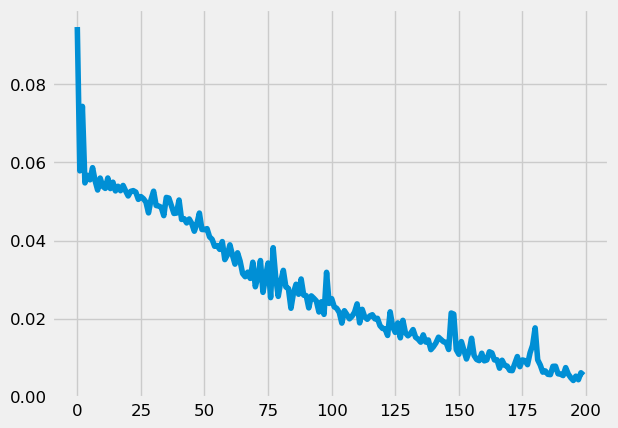

In [37]:
plt.plot(range(len(loss_per_epoch)), loss_per_epoch)

In [38]:
ultimo_batch_treino = scaled_treino[-6:]

In [39]:
ultimo_batch_treino = ultimo_batch_treino.reshape((1, n_input, n_features))

In [40]:
modelo.predict(ultimo_batch_treino)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


array([[0.6084585]], dtype=float32)

In [41]:
previsoes_teste = []

In [42]:
first_eval_batch = scaled_treino[-n_input:]

In [43]:
current_batch = first_eval_batch.reshape((1, n_input, n_features))

In [44]:
current_batch

array([[[1.        ],
        [0.58833469],
        [0.56353068],
        [0.49925656],
        [0.70769127],
        [0.80569073]]])

In [45]:
dados_teste.head()

,Vendas
Mes,
2021-04-01,18316
2021-05-01,15190
2021-06-01,17727
2021-07-01,18434
2021-08-01,12483


In [46]:
for i in range(len(dados_teste)):
    current_pred = modelo.predict(current_batch)[0]

    previsoes_teste.append(current_pred)

    current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [47]:
previsoes_teste

[array([0.6084585], dtype=float32),
 array([0.6222484], dtype=float32),
 array([0.5575547], dtype=float32),
 array([0.7051538], dtype=float32),
 array([0.69551647], dtype=float32),
 array([0.65740967], dtype=float32),
 array([0.6077608], dtype=float32),
 array([0.6183785], dtype=float32),
 array([0.63077044], dtype=float32),
 array([0.6470916], dtype=float32),
 array([0.61303115], dtype=float32),
 array([0.58677596], dtype=float32)]

In [48]:
true_previsoes_teste = scaler.inverse_transform(previsoes_teste)

In [49]:
dados_teste['Previsao'] = true_previsoes_teste

In [50]:
dados_teste.head()

,Vendas,Previsao
Mes,,
2021-04-01,18316,18795.752247
2021-05-01,15190,18999.787492
2021-06-01,17727,18042.579664
2021-07-01,18434,20226.455964
2021-08-01,12483,20083.861647


In [51]:
dados_teste.tail()

,Vendas,Previsao
Mes,,
2021-11-01,14568,18942.528582
2021-12-01,15661,19125.879502
2022-01-01,19108,19367.367715
2022-02-01,19202,18863.408879
2022-03-01,13623,18474.937083


<Axes: xlabel='Mes'>

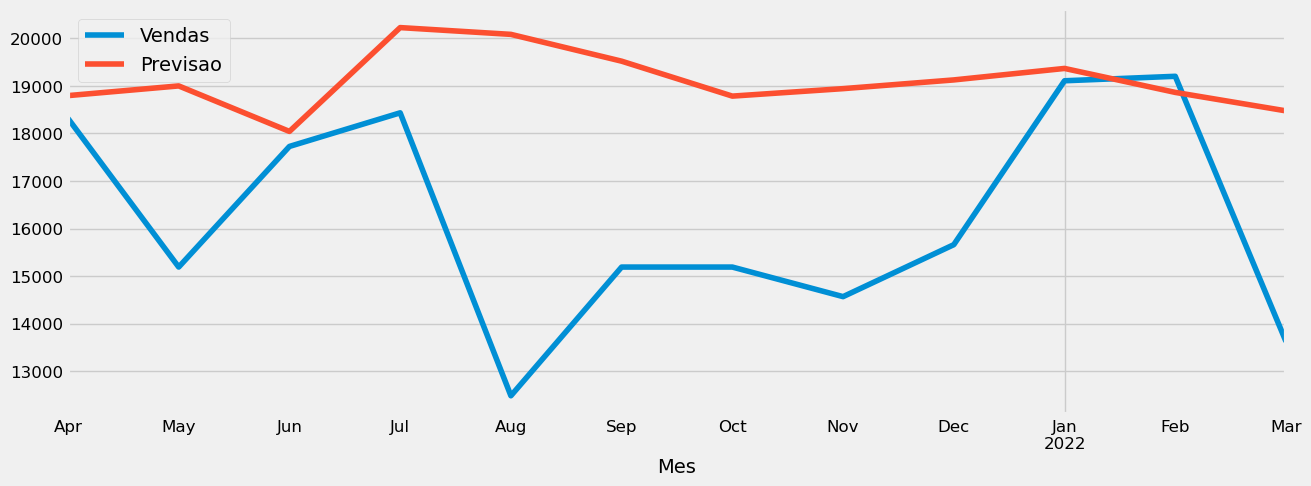

In [52]:
dados_teste.plot(figsize = (14,5))

In [ ]:
rmse = sqrt(mean_squared_error(dados_teste['Vendas'], dados_teste['Previsao']))

In [54]:
print(rmse)

3678.4465180449783


In [55]:
n_input = 12

In [56]:
generator = TimeseriesGenerator(scaled_treino, scaled_treino, length = n_input, batch_size = 1)

In [57]:
X, y = generator[0]

In [58]:
X.shape

(1, 12, 1)

In [59]:
y.shape

(1, 1)

In [60]:
print(f'Array de Entrada (x): {X.flatten()}')
print(f'Previsão (y): {y}')

Array de Entrada (x): [0.288186   0.38402271 0.31974858 0.39659367 0.17315491 0.36476075
 0.27987294 0.21857259 0.4699243  0.32562855 0.32447959 0.32069478]
Previsão (y): [[0.32116788]]


In [61]:
n_features = 1

In [62]:
modelo = Sequential()
modelo.add(LSTM(200, activation = 'relu', input_shape = (n_input, n_features)))
modelo.add(Dense(1))
modelo.compile(optimizer= 'adam', loss = 'mse')

In [63]:
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 200)            │       161,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,801 (632.04 KB)

 Trainable params: 161,801 (632.04 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
modelo.fit(generator, epochs=200)

Epoch 1/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1635
Epoch 2/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1129
Epoch 3/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0663
Epoch 4/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0682
Epoch 5/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0646
Epoch 6/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0662
Epoch 7/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0592
Epoch 8/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0612
Epoch 9/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0700
Epoch 10/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0634
Epoch 11/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0661
Epoch 12/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0500
Epoch 13/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0515
Epoch 14/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0644
Epoch 15/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0644
Epoc

In [65]:
loss_per_epoch = modelo.history.history['loss']

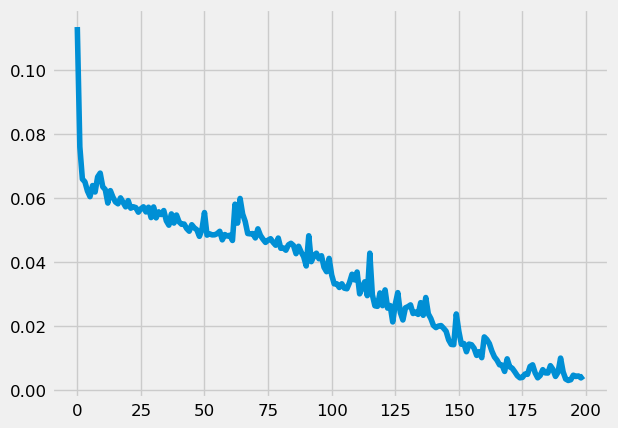

In [66]:
plt.plot(range(len(loss_per_epoch)), loss_per_epoch)

In [67]:
ultimo_batch_treino = scaled_treino[-12:]

In [68]:
ultimo_batch_treino = ultimo_batch_treino.reshape((1, n_input, n_features))

In [69]:
modelo.predict(ultimo_batch_treino)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


array([[0.8673948]], dtype=float32)

In [70]:
previsoes_teste = []

In [71]:
first_eval_batch = scaled_treino[-n_input:]

In [72]:
first_eval_batch = scaled_treino[-n_input:]  

current_batch = first_eval_batch.reshape((1, n_input, n_features))
previsoes_teste = []

for i in range(len(dados_teste)):
    current_pred = modelo.predict(current_batch)[0]
    previsoes_teste.append(current_pred)
    current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

true_previsoes_teste = scaler.inverse_transform(previsoes_teste)
dados_teste['Previsao2'] = true_previsoes_teste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [73]:
dados_teste.head()

,Vendas,Previsao,Previsao2
Mes,,,
2021-04-01,18316,18795.752247,22626.973534
2021-05-01,15190,18999.787492,23216.109033
2021-06-01,17727,18042.579664,23086.711622
2021-07-01,18434,20226.455964,22587.635924
2021-08-01,12483,20083.861647,21872.901403


In [74]:
rmse = sqrt(mean_squared_error(dados_teste['Vendas'], dados_teste['Previsao2']))

In [75]:
print(rmse)

11649.415483437968
